# Week 2 DolphinDB Query Practice

**Task:** DolphinDB 基础取数：掌握 `loadTable`、过滤、聚合、`context by`、`bar`、`aj/ej`、时间字段处理。

**Deliverables:** 三类行情样例查询、字段缺失率图、逐日数据量柱状图。

**Scope:** 本 notebook 只分析 **A 股股票 Level-2 行情数据**，明确过滤掉 SHFE / INE 等期货合约。

## 1. Environment Setup
连接 DolphinDB，并加载常用 Python 工具库。

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dolphindb as ddb

sys.path.append(os.path.abspath(".."))
from src.ddb_client import connect_ddb

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

s = connect_ddb()
print("DolphinDB connected.")

DolphinDB connected.


## 2. Parameters
统一管理数据库路径、日期区间、样本量和股票过滤条件。后面所有查询都引用这里的变量，避免重复代码。

In [3]:
db_path = "dfs://quota"
start_date = "2026.03.11"
end_date = "2026.04.10"
sample_size = 10
sample_limit = 10000

# A-share equity filter only. This removes futures such as ag2606.SHFE, au2608.SHFE, sc2605.INE.
stock_filter_sql = """
(
       code like "00%.SZ"
    or code like "30%.SZ"
    or code like "60%.SH"
    or code like "68%.SH"
)
"""

print("db_path:", db_path)
print("date range:", start_date, "to", end_date)
print("sample_size:", sample_size)
print("sample_limit per table:", sample_limit)

db_path: dfs://quota
date range: 2026.03.11 to 2026.04.10
sample_size: 10
sample_limit per table: 10000


## 3. Helper Functions
把常用逻辑写成函数：代码列表格式、时间字段处理、session 分类、缺失率计算、简短结论打印。

In [4]:
def make_code_list(codes):
    # Convert Python list of codes into DolphinDB symbol list syntax.
    if not codes:
        raise ValueError("codes cannot be empty")
    return "`" + "`".join(codes)


def add_datetime(input_df):
    # Create a Python datetime column from DolphinDB date and time columns.
    output_df = input_df.copy()
    if "date" not in output_df.columns or "time" not in output_df.columns:
        return output_df
    date_part = pd.to_datetime(output_df["date"], errors="coerce").dt.strftime("%Y-%m-%d")
    time_part = pd.to_datetime(output_df["time"], errors="coerce").dt.strftime("%H:%M:%S.%f")
    output_df["datetime"] = pd.to_datetime(date_part + " " + time_part, errors="coerce")
    return output_df


def add_session(input_df):
    # Classify observations into major A-share trading sessions.
    output_df = input_df.copy()
    if "time" not in output_df.columns:
        output_df["session"] = "unknown"
        return output_df
    t = pd.to_datetime(output_df["time"], errors="coerce").dt.time
    output_df["session"] = "other"
    output_df.loc[(t >= pd.to_datetime("09:15:00").time()) & (t < pd.to_datetime("09:30:00").time()), "session"] = "opening_call_auction"
    output_df.loc[(t >= pd.to_datetime("09:30:00").time()) & (t <= pd.to_datetime("11:30:00").time()), "session"] = "morning_continuous"
    output_df.loc[(t >= pd.to_datetime("13:00:00").time()) & (t <= pd.to_datetime("15:00:00").time()), "session"] = "afternoon_continuous"
    return output_df


def get_missing_rate(input_df, table_name):
    output = input_df.isna().mean().reset_index()
    output.columns = ["field", "missing_rate"]
    output["table"] = table_name
    return output


def print_conclusion(title, bullets):
    print()
    print("=" * 80)
    print(title)
    print("=" * 80)
    for idx, bullet in enumerate(bullets, 1):
        print(f"{idx}. {bullet}")

## 4. Schema Check: qtick / qorder / qknock
先查表结构，不直接全表拉取。

In [5]:
tables = {
    "qtick": "Quote / order book snapshot",
    "qorder": "Order submission and cancellation records",
    "qknock": "Executed trade records"
}

schemas = {}
for table_name, description in tables.items():
    print()
    print("=" * 80)
    print(f"{table_name}: {description}")
    print("=" * 80)
    query = f'''schema(loadTable("{db_path}", "{table_name}")).colDefs'''
    schemas[table_name] = s.run(query)
    display(schemas[table_name])


qtick: Quote / order book snapshot


,name,typeString,typeInt,extra,comment,sensitive
0,code,SYMBOL,17,NaN,,False
1,date,DATE,6,NaN,,False
2,time,TIME,8,NaN,,False
3,src,CHAR,2,NaN,,False
4,state,CHAR,2,NaN,,False
...,...,...,...,...,...,...
73,exercise_date,INT,4,NaN,,False
74,exercise_price,DOUBLE,16,NaN,,False
75,cp_flag,CHAR,2,NaN,,False
76,underlying_code,STRING,18,NaN,,False



qorder: Order submission and cancellation records


,name,typeString,typeInt,extra,comment,sensitive
0,code,SYMBOL,17,NaN,,False
1,date,DATE,6,NaN,,False
2,time,TIME,8,NaN,,False
3,order_no,LONG,5,NaN,,False
4,bs_flag,CHAR,2,NaN,,False
5,order_type,CHAR,2,NaN,,False
6,order_price,DOUBLE,16,NaN,,False
7,order_volume,LONG,5,NaN,,False



qknock: Executed trade records


,name,typeString,typeInt,extra,comment,sensitive
0,code,SYMBOL,17,NaN,,False
1,date,DATE,6,NaN,,False
2,time,TIME,8,NaN,,False
3,match_no,LONG,5,NaN,,False
4,bid_order_no,LONG,5,NaN,,False
5,ask_order_no,LONG,5,NaN,,False
6,match_price,LONG,5,NaN,,False
7,match_volume,LONG,5,NaN,,False


**Conclusion**

- `qtick` 更适合观察盘口快照和价格变化。
- `qorder` 更适合分析订单提交、撤单和委托方向。
- `qknock` 更适合分析成交记录和实际交易量。

## 5. Select A-share Sample Universe
从 `qtick` 中选择指定日期区间内记录数最多的 A 股代码，显式过滤期货。

In [6]:
sample_code_query = f'''
select top {sample_size} code, count(*) as n_obs
from loadTable("{db_path}", "qtick")
where date >= {start_date}
  and date <= {end_date}
  and {stock_filter_sql}
group by code
order by n_obs desc
'''

code_df = s.run(sample_code_query)
display(code_df)

sample_codes = code_df["code"].tolist()
code_list = make_code_list(sample_codes)

print("Selected A-share stock codes:", sample_codes)
print("DolphinDB code list:", code_list)

,code,n_obs
0,601318.SH,110146
1,600105.SH,110144
2,600879.SH,110143
3,601016.SH,110143
4,601857.SH,110142
5,600900.SH,110142
6,601669.SH,110141
7,601390.SH,110141
8,600150.SH,110141
9,600905.SH,110141


Selected A-share stock codes: ['601318.SH', '600105.SH', '600879.SH', '601016.SH', '601857.SH', '600900.SH', '601669.SH', '601390.SH', '600150.SH', '600905.SH']
DolphinDB code list: `601318.SH`600105.SH`600879.SH`601016.SH`601857.SH`600900.SH`601669.SH`601390.SH`600150.SH`600905.SH


**Conclusion**

这一步先定义干净股票池。若直接按行情记录数排序，容易选到 `ag2606.SHFE`、`au2608.SHFE`、`sc2605.INE` 等期货合约。

## 6. Sample Query: Three Market Data Tables 三类行情样例查询
This section queries three core Level-2 market data tables: `qtick`, `qorder`, and `qknock`.

These tables describe the market from three perspectives:

| Table | Meaning | Market Perspective |
|---|---|---|
| `qtick` | Quote / order book snapshot | Market state |
| `qorder` | Order submission / cancellation records | Market intention |
| `qknock` | Executed trade records | Market execution |

#### 6.1 qtick: Market State Snapshot
What does the order book look like at a given time?

`qtick` captures the current market state, including best bid/ask prices, order book depth, latest price, and accumulated volume.

In [7]:
sample_queries = {
    "qtick": f'''
        select top {sample_limit} *
        from loadTable("{db_path}", "qtick")
        where date >= {start_date}
          and date <= {end_date}
          and code in {code_list}
        order by code, date, time
    ''',
    "qorder": f'''
        select top {sample_limit} *
        from loadTable("{db_path}", "qorder")
        where date >= {start_date}
          and date <= {end_date}
          and code in {code_list}
        order by code, date, time
    ''',
    "qknock": f'''
        select top {sample_limit} *
        from loadTable("{db_path}", "qknock")
        where date >= {start_date}
          and date <= {end_date}
          and code in {code_list}
        order by code, date, time
    '''
}

qtick = s.run(sample_queries["qtick"])
qorder = s.run(sample_queries["qorder"])
qknock = s.run(sample_queries["qknock"])

sample_data = {"qtick": qtick, "qorder": qorder, "qknock": qknock}
for table_name, table_df in sample_data.items():
    print()
    print("=" * 80)
    print(table_name)
    print("=" * 80)
    print("shape:", table_df.shape)
    display(table_df.head())


qtick
shape: (10000, 78)


,code,date,time,src,state,bp0,bp1,bp2,bp3,bp4,...,create_date,list_date,expire_date,start_settle_date,end_settle_date,exercise_date,exercise_price,cp_flag,underlying_code,trading_date
0,600105.SH,2026-03-11,1970-01-01 08:00:00,0,0,0.00,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
1,600105.SH,2026-03-11,1970-01-01 08:45:21,0,0,0.00,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
2,600105.SH,2026-03-11,1970-01-01 09:14:00,0,0,0.00,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
3,600105.SH,2026-03-11,1970-01-01 09:15:00,0,0,0.00,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0
4,600105.SH,2026-03-11,1970-01-01 09:15:03,0,0,28.06,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0.0,0,,0



qorder
shape: (10000, 8)


,code,date,time,order_no,bs_flag,order_type,order_price,order_volume
0,600105.SH,2026-03-11,1970-01-01 09:15:00.220,548,2,0,309600.0,100
1,600105.SH,2026-03-11,1970-01-01 09:15:00.250,986,2,0,291000.0,100
2,600105.SH,2026-03-11,1970-01-01 09:15:00.250,990,2,0,300300.0,100
3,600105.SH,2026-03-11,1970-01-01 09:15:00.250,1002,2,0,309300.0,100
4,600105.SH,2026-03-11,1970-01-01 09:15:00.380,1987,2,0,309700.0,400



qknock
shape: (10000, 8)


,code,date,time,match_no,bid_order_no,ask_order_no,match_price,match_volume
0,600105.SH,2026-03-11,1970-01-01 09:25:01.210,347947,11162,506906,282000,100
1,600105.SH,2026-03-11,1970-01-01 09:25:01.210,347948,11162,506930,282000,100
2,600105.SH,2026-03-11,1970-01-01 09:25:01.210,347833,15257,11322,282000,100
3,600105.SH,2026-03-11,1970-01-01 09:25:01.210,347834,16977,11322,282000,100
4,600105.SH,2026-03-11,1970-01-01 09:25:01.210,347835,31817,11322,282000,500


**Conclusion**

三张表都可以通过 `loadTable` + `where` 条件完成基础取数。`top` 用于 notebook 预览和练习；正式研究建议先在 DolphinDB 端聚合。

| Table | Core Question | Suitable Analysis |
|---|---|---|
| `qtick` | What is the market state? | Spread, depth, imbalance, quote dynamics |
| `qorder` | What are investors trying to do? | Order flow, cancellation, buy/sell pressure |
| `qknock` | What actually traded? | Trade intensity, VWAP, execution analysis |

Together, the three tables form a complete Level-2 market view:

`qtick` describes **market state**,  
`qorder` describes **market intention**,  
and `qknock` describes **market execution**.

## 7. Time Field Processing
将 `date` 和 `time` 合成为 Python `datetime`。

In [8]:
qtick = add_datetime(qtick)
qorder = add_datetime(qorder)
qknock = add_datetime(qknock)

sample_data = {"qtick": qtick, "qorder": qorder, "qknock": qknock}
for table_name, table_df in sample_data.items():
    print()
    print("=" * 80)
    print(f"{table_name} datetime check")
    print("=" * 80)
    columns_to_show = [col for col in ["code", "date", "time", "datetime"] if col in table_df.columns]
    display(table_df[columns_to_show].head())
    if "datetime" in table_df.columns:
        print("datetime missing rate:", round(table_df["datetime"].isna().mean(), 4))


qtick datetime check


,code,date,time,datetime
0,600105.SH,2026-03-11,1970-01-01 08:00:00,2026-03-11 08:00:00
1,600105.SH,2026-03-11,1970-01-01 08:45:21,2026-03-11 08:45:21
2,600105.SH,2026-03-11,1970-01-01 09:14:00,2026-03-11 09:14:00
3,600105.SH,2026-03-11,1970-01-01 09:15:00,2026-03-11 09:15:00
4,600105.SH,2026-03-11,1970-01-01 09:15:03,2026-03-11 09:15:03


datetime missing rate: 0.0

qorder datetime check


,code,date,time,datetime
0,600105.SH,2026-03-11,1970-01-01 09:15:00.220,2026-03-11 09:15:00.220
1,600105.SH,2026-03-11,1970-01-01 09:15:00.250,2026-03-11 09:15:00.250
2,600105.SH,2026-03-11,1970-01-01 09:15:00.250,2026-03-11 09:15:00.250
3,600105.SH,2026-03-11,1970-01-01 09:15:00.250,2026-03-11 09:15:00.250
4,600105.SH,2026-03-11,1970-01-01 09:15:00.380,2026-03-11 09:15:00.380


datetime missing rate: 0.0

qknock datetime check


,code,date,time,datetime
0,600105.SH,2026-03-11,1970-01-01 09:25:01.210,2026-03-11 09:25:01.210
1,600105.SH,2026-03-11,1970-01-01 09:25:01.210,2026-03-11 09:25:01.210
2,600105.SH,2026-03-11,1970-01-01 09:25:01.210,2026-03-11 09:25:01.210
3,600105.SH,2026-03-11,1970-01-01 09:25:01.210,2026-03-11 09:25:01.210
4,600105.SH,2026-03-11,1970-01-01 09:25:01.210,2026-03-11 09:25:01.210


datetime missing rate: 0.0


**Conclusion**

时间字段处理是 Level-2 数据分析的基础。完成 `datetime` 后，才可以稳定进行分钟聚合、session 切分和表间时间对齐。

## 8. Data Quality Assessment
Before constructing quantitative features, we first evaluate whether the sampled Level-2 data is complete, internally consistent, and suitable for downstream market microstructure research.

Unlike conventional datasets, apparent missing values in high-frequency market data may reflect trading mechanisms rather than data quality issues. Therefore, this section focuses on distinguishing physical missing values from market-generated special values.

### 8.1 Physical Data Completeness

#### Research Question
Does the sampled Level-2 dataset contain physical missing values or incomplete trading days?

#### 8.1.1 Null/NaN Detection

In [9]:
missing_df = pd.concat(
    [get_missing_rate(table_df, table_name) for table_name, table_df in sample_data.items()],
    ignore_index=True
)

missing_df = missing_df.sort_values(["table", "missing_rate"], ascending=[True, False])
display(missing_df.head(30))

top_missing = missing_df[missing_df["missing_rate"] > 0].copy()
if top_missing.empty:
    print("No missing values detected in the sampled data.")
else:
    top_missing = top_missing.sort_values("missing_rate", ascending=False).head(25)
    labels = top_missing["table"] + "." + top_missing["field"]
    plt.figure(figsize=(12, 6))
    plt.barh(labels, top_missing["missing_rate"])
    plt.gca().invert_yaxis()
    plt.xlabel("Missing rate")
    plt.title("Top Missing Fields Across qtick / qorder / qknock")
    plt.tight_layout()
    plt.show()

,field,missing_rate,table
88,code,0.0,qknock
89,date,0.0,qknock
90,time,0.0,qknock
91,match_no,0.0,qknock
92,bid_order_no,0.0,qknock
93,ask_order_no,0.0,qknock
94,match_price,0.0,qknock
95,match_volume,0.0,qknock
96,datetime,0.0,qknock
79,code,0.0,qorder


No missing values detected in the sampled data.


In [10]:
if missing_df["missing_rate"].max() == 0:
    print_conclusion(
        "Missing Rate Conclusion",
        [
            "The sampled Level-2 data contains no missing values across the inspected fields.",
            "This suggests the raw sample is complete enough for basic query practice and preliminary analysis.",
            "For production research, repeat the same check after expanding the date range and stock universe."
        ]
    )
else:
    high_missing = missing_df[missing_df["missing_rate"] > 0].sort_values("missing_rate", ascending=False).head(5)
    print_conclusion(
        "Missing Rate Conclusion",
        [
            "Some fields contain missing values, so downstream analysis should avoid assuming every field is fully populated.",
            "Missingness should be interpreted by field type: raw market fields, derived fields, and optional fields may have different meanings.",
            "The highest-missing fields are shown below and should be checked before being used as features."
        ]
    )
    display(high_missing)


Missing Rate Conclusion
1. The sampled Level-2 data contains no missing values across the inspected fields.
2. This suggests the raw sample is complete enough for basic query practice and preliminary analysis.
3. For production research, repeat the same check after expanding the date range and stock universe.


#### 8.1.2 Data Coverage

In [11]:
tables = ["qtick", "qorder", "qknock"]
daily_list = []

for table in tables:
    query = f"""
    select date,
           count(*) as n_rows
    from loadTable("{db_path}", "{table}")
    where date >= {start_date}
      and date <= {end_date}
      and code in {code_list}
    group by date
    order by date
    """
    
    temp = s.run(query)
    temp["table"] = table
    daily_list.append(temp)

daily_volume = pd.concat(daily_list, ignore_index=True)
daily_volume["date"] = daily_volume["date"].astype(str)

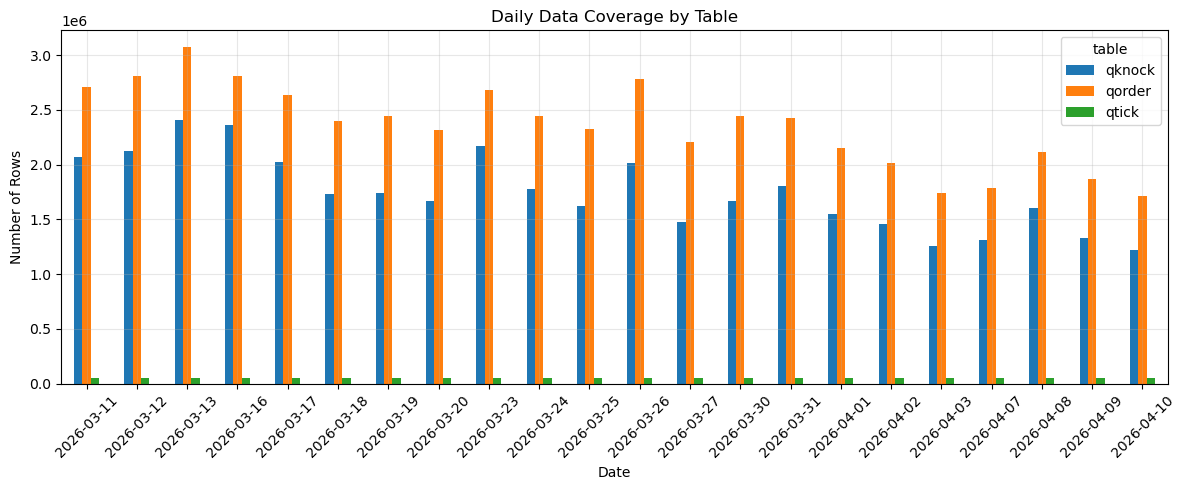

In [12]:
pivot_daily = daily_volume.pivot(index="date", columns="table", values="n_rows")

pivot_daily.plot(kind="bar", figsize=(12, 5))

plt.title("Daily Data Coverage by Table")
plt.xlabel("Date")
plt.ylabel("Number of Rows")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

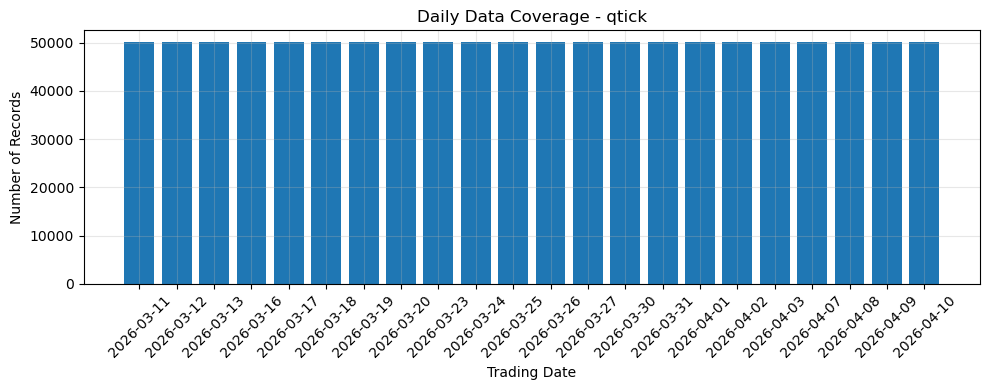

,date,n_rows
0,2026-03-11,50061
1,2026-03-12,50068
2,2026-03-13,50060
3,2026-03-16,50066
4,2026-03-17,50063
5,2026-03-18,50068
6,2026-03-19,50060
7,2026-03-20,50068
8,2026-03-23,50062
9,2026-03-24,50060


In [13]:
qtick_daily_query = f"""
select date,
       count(*) as n_rows
from loadTable("{db_path}", "qtick")
where date >= {start_date}
  and date <= {end_date}
  and code in {code_list}
group by date
order by date
"""

qtick_daily = s.run(qtick_daily_query)
qtick_daily["date"] = qtick_daily["date"].astype(str)

plt.figure(figsize=(10,4))

plt.bar(qtick_daily["date"], qtick_daily["n_rows"])

plt.title("Daily Data Coverage - qtick")
plt.xlabel("Trading Date")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

display(qtick_daily)

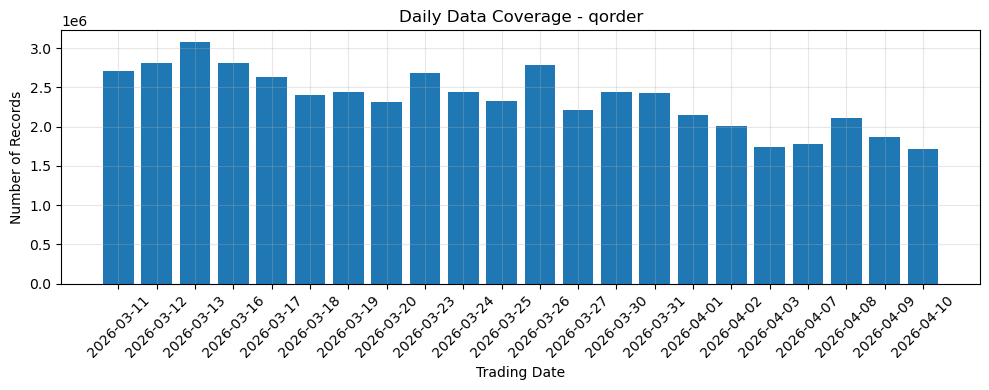

,date,n_rows
0,2026-03-11,2706801
1,2026-03-12,2807221
2,2026-03-13,3073619
3,2026-03-16,2807139
4,2026-03-17,2637983
5,2026-03-18,2399361
6,2026-03-19,2445549
7,2026-03-20,2315188
8,2026-03-23,2683371
9,2026-03-24,2447602


In [14]:
qorder_daily_query = f"""
select date,
       count(*) as n_rows
from loadTable("{db_path}", "qorder")
where date >= {start_date}
  and date <= {end_date}
  and code in {code_list}
group by date
order by date
"""

qorder_daily = s.run(qorder_daily_query)
qorder_daily["date"] = qorder_daily["date"].astype(str)

plt.figure(figsize=(10,4))

plt.bar(qorder_daily["date"], qorder_daily["n_rows"])

plt.title("Daily Data Coverage - qorder")
plt.xlabel("Trading Date")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

display(qorder_daily)

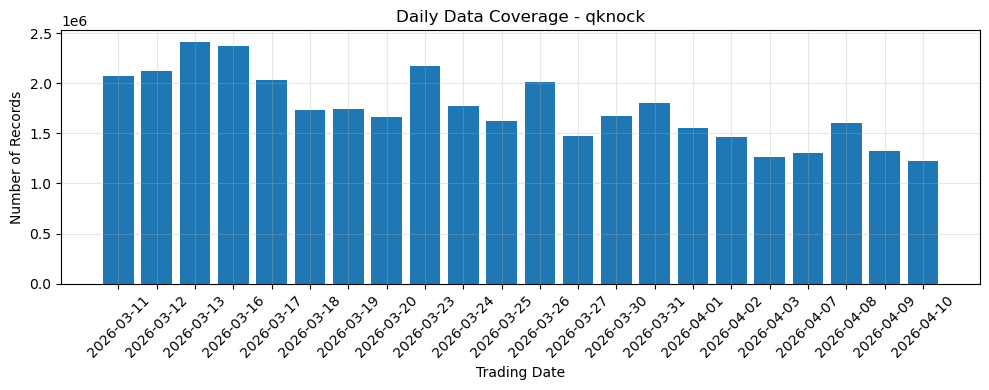

,date,n_rows
0,2026-03-11,2067720
1,2026-03-12,2125495
2,2026-03-13,2406303
3,2026-03-16,2366717
4,2026-03-17,2028920
5,2026-03-18,1731689
6,2026-03-19,1739136
7,2026-03-20,1666693
8,2026-03-23,2169605
9,2026-03-24,1774853


In [15]:
qknock_daily_query = f"""
select date,
       count(*) as n_rows
from loadTable("{db_path}", "qknock")
where date >= {start_date}
  and date <= {end_date}
  and code in {code_list}
group by date
order by date
"""

qknock_daily = s.run(qknock_daily_query)
qknock_daily["date"] = qknock_daily["date"].astype(str)

plt.figure(figsize=(10,4))

plt.bar(qknock_daily["date"], qknock_daily["n_rows"])

plt.title("Daily Data Coverage - qknock")
plt.xlabel("Trading Date")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

display(qknock_daily)

In [16]:
print(f"qtick:")
print(f"Trading days : {len(qtick_daily)}")
print(f"Average rows : {qtick_daily['n_rows'].mean():,.0f}")
print(f"Minimum rows : {qtick_daily['n_rows'].min():,.0f}")
print(f"Maximum rows : {qtick_daily['n_rows'].max():,.0f}")
print(f"Std / Mean   : {qtick_daily['n_rows'].std()/qtick_daily['n_rows'].mean():.2%}")
cv = qtick_daily["n_rows"].std() / qtick_daily["n_rows"].mean()

print(f"Coefficient of Variation (CV): {cv:.2%}")

qtick:
Trading days : 22
Average rows : 50,065
Minimum rows : 50,060
Maximum rows : 50,070
Std / Mean   : 0.01%
Coefficient of Variation (CV): 0.01%


In [17]:
print(f"qorder:")
print(f"Trading days : {len(qorder_daily)}")
print(f"Average rows : {qorder_daily['n_rows'].mean():,.0f}")
print(f"Minimum rows : {qorder_daily['n_rows'].min():,.0f}")
print(f"Maximum rows : {qorder_daily['n_rows'].max():,.0f}")
print(f"Std / Mean   : {qorder_daily['n_rows'].std()/qorder_daily['n_rows'].mean():.2%}")
cv = qorder_daily["n_rows"].std() / qorder_daily["n_rows"].mean()

print(f"Coefficient of Variation (CV): {cv:.2%}")

qorder:
Trading days : 22
Average rows : 2,360,091
Minimum rows : 1,716,012
Maximum rows : 3,073,619
Std / Mean   : 16.10%
Coefficient of Variation (CV): 16.10%


In [18]:
print(f"qknock:")
print(f"Trading days : {len(qknock_daily)}")
print(f"Average rows : {qknock_daily['n_rows'].mean():,.0f}")
print(f"Minimum rows : {qknock_daily['n_rows'].min():,.0f}")
print(f"Maximum rows : {qknock_daily['n_rows'].max():,.0f}")
print(f"Std / Mean   : {qknock_daily['n_rows'].std()/qknock_daily['n_rows'].mean():.2%}")
cv = qknock_daily["n_rows"].std() / qknock_daily["n_rows"].mean()

print(f"Coefficient of Variation (CV): {cv:.2%}")

qknock:
Trading days : 22
Average rows : 1,745,151
Minimum rows : 1,221,767
Maximum rows : 2,406,303
Std / Mean   : 19.87%
Coefficient of Variation (CV): 19.87%


Summary

The qtick table demonstrates extremely stable daily coverage. Record counts remain nearly identical across all 22 trading days (CV = 0.01%), indicating highly consistent quote-level data collection without observable missing trading days.

The qorder table shows greater variation in daily record counts (CV = 16.10%). This variation is expected because order submissions and cancellations depend on daily market activity rather than reflecting data quality issues.

Daily transaction records fluctuate more substantially (CV = 19.87%), reflecting changes in market trading activity. No evidence suggests systematic data loss or incomplete transaction recording.

The three Level-2 tables exhibit different daily coverage characteristics due to their distinct market functions.

- **qtick** (快照表)：每日数据量极度稳定（CV = 0.01%），说明行情快照的生成是系统性的、由交易所固定频率推送，与市场活跃度无关。这符合预期，是高质量的基础数据源。
- **qorder** (委托表)：每日数据量存在中等波动（CV = 16.10%），其变化与市场成交量、投资者参与度密切相关。例如，2026-03-13 的数据量最高，可以结合当日市场行情（如重大政策发布）进一步验证。无明显证据表明存在数据丢失。
- **qknock** (成交表)：每日数据量波动最大（CV = 19.87%），这与市场交易活跃度直接相关。这也验证了成交数据是高频分析中最具信息价值的“信号”源，其数据量本身就是市场情绪的反映。

Overall, no abnormal drops in daily record counts are observed, suggesting that the sampled Level-2 database provides reliable and continuous coverage throughout the study period.

### 8.3 Investigation of Special Value
这些字段为 0 不一定是错，但需要判断是不是 hidden missing

In [19]:
import pandas as pd
import numpy as np

def add_time_bucket(df):
    df = df.copy()
    
    if "time" in df.columns:
        t = pd.to_datetime(df["time"].astype(str), errors="coerce").dt.time
        
        df["time_bucket"] = np.select(
            [
                t < pd.to_datetime("09:15:00").time(),
                (t >= pd.to_datetime("09:15:00").time()) & (t < pd.to_datetime("09:25:00").time()),
                (t >= pd.to_datetime("09:25:00").time()) & (t < pd.to_datetime("09:30:00").time()),
                (t >= pd.to_datetime("09:30:00").time()) & (t <= pd.to_datetime("11:30:00").time()),
                (t >= pd.to_datetime("13:00:00").time()) & (t <= pd.to_datetime("15:00:00").time())
            ],
            [
                "pre_open",
                "opening_call_auction",
                "pre_continuous_buffer",
                "morning_continuous",
                "afternoon_continuous"
            ],
            default="other"
        )
    else:
        df["time_bucket"] = "unknown"
        
    return df


qtick_sv = add_time_bucket(qtick)
qorder_sv = add_time_bucket(qorder)
qknock_sv = add_time_bucket(qknock)

#### 8.3.1 Special Value Overview
##### Research Question
Why are new_price, new_volume and new_amount equal to zero?

In [20]:
special_value_summary = []

def add_special_value(table_name, df, field, condition, interpretation):
    count = condition.sum()
    total = len(df)
    
    special_value_summary.append({
        "table": table_name,
        "field": field,
        "special_value_count": int(count),
        "total_rows": int(total),
        "special_value_rate": count / total if total > 0 else np.nan,
        "interpretation": interpretation
    })


# qtick
add_special_value(
    "qtick",
    qtick_sv,
    "new_price == 0",
    qtick_sv["new_price"] == 0,
    "No executed trade price in this snapshot"
)

add_special_value(
    "qtick",
    qtick_sv,
    "new_volume == 0",
    qtick_sv["new_volume"] == 0,
    "No executed trade volume in this snapshot"
)

add_special_value(
    "qtick",
    qtick_sv,
    "bp0/ap0 <= 0",
    (qtick_sv["bp0"] <= 0) | (qtick_sv["ap0"] <= 0),
    "Best quote unavailable, usually before order book initialization"
)

# qorder
add_special_value(
    "qorder",
    qorder_sv,
    "order_price == 0",
    qorder_sv["order_price"] == 0,
    "Possible special order type or market order"
)

# qknock
add_special_value(
    "qknock",
    qknock_sv,
    "match_price <= 0",
    qknock_sv["match_price"] <= 0,
    "Invalid executed price if present"
)

add_special_value(
    "qknock",
    qknock_sv,
    "match_volume <= 0",
    qknock_sv["match_volume"] <= 0,
    "Invalid executed volume if present"
)


special_value_summary = pd.DataFrame(special_value_summary)

special_value_summary["special_value_rate"] = (
    special_value_summary["special_value_rate"]
    .map(lambda x: f"{x:.2%}")
)

print("=== Special Value Overview ===")
display(special_value_summary)


=== Special Value Overview ===


,table,field,special_value_count,total_rows,special_value_rate,interpretation
0,qtick,new_price == 0,408,10000,4.08%,No executed trade price in this snapshot
1,qtick,new_volume == 0,523,10000,5.23%,No executed trade volume in this snapshot
2,qtick,bp0/ap0 <= 0,8,10000,0.08%,"Best quote unavailable, usually before order b..."
3,qorder,order_price == 0,345,10000,3.45%,Possible special order type or market order
4,qknock,match_price <= 0,0,10000,0.00%,Invalid executed price if present
5,qknock,match_volume <= 0,0,10000,0.00%,Invalid executed volume if present


##### Special Value Overview

Although the sampled Level-2 tables contain almost no physical missing values, several zero-value patterns appear in key market fields.

In `qtick`, `new_price == 0` accounts for 4.08% of observations, while `new_volume == 0` accounts for 5.23%. These cases are not immediately treated as missing values because quote snapshots may exist even when no trade is executed.

For quote fields, only 0.08% of observations have invalid or unavailable best bid / ask quotes, suggesting that the top-of-book information is highly complete.

In `qorder`, `order_price == 0` appears in 3.45% of observations. Since this may be related to special order types or market-order encoding, it requires further investigation by order type.

In `qknock`, no invalid executed price or volume is observed, indicating that transaction records pass the basic validity check.

#### 8.3.2 qtick:new_price==0

In [21]:
qtick_zero_price = qtick_sv[qtick_sv["new_price"] == 0].copy()

qtick_zero_price_by_bucket = (
    qtick_zero_price["time_bucket"]
    .value_counts()
    .rename_axis("time_bucket")
    .reset_index(name="count")
)

print("new_price == 0 by time bucket:")
display(qtick_zero_price_by_bucket)

display(
    qtick_zero_price[
        [
            "code", "date", "time", "time_bucket",
            "state", "bp0", "ap0", "bv0", "av0",
            "new_price", "new_volume", "new_amount"
        ]
    ].head(5)
)

new_price == 0 by time bucket:


,time_bucket,count
0,opening_call_auction,400
1,pre_open,6
2,pre_continuous_buffer,2


,code,date,time,time_bucket,state,bp0,ap0,bv0,av0,new_price,new_volume,new_amount
0,600105.SH,2026-03-11,1970-01-01 08:00:00,pre_open,0,0.00,0.00,0,0,0.0,0,0.0
1,600105.SH,2026-03-11,1970-01-01 08:45:21,pre_open,0,0.00,0.00,0,0,0.0,0,0.0
2,600105.SH,2026-03-11,1970-01-01 09:14:00,pre_open,0,0.00,0.00,0,0,0.0,0,0.0
3,600105.SH,2026-03-11,1970-01-01 09:15:00,opening_call_auction,0,0.00,0.00,0,0,0.0,0,0.0
4,600105.SH,2026-03-11,1970-01-01 09:15:03,opening_call_auction,0,28.06,28.06,2600,2600,0.0,0,0.0


In [22]:
quote_ready = (
    (qtick_zero_price["bp0"] > 0) &
    (qtick_zero_price["ap0"] > 0)
)

quote_ready_summary = pd.DataFrame([
    {
        "Metric": "new_price == 0 observations",
        "Count": len(qtick_zero_price)
    },
    {
        "Metric": "Best bid & ask already available",
        "Count": quote_ready.sum()
    },
    {
        "Metric": "Availability Rate",
        "Count": f"{quote_ready.mean():.2%}"
    }
])

print("Quote Availability among new_price == 0 Records")
display(quote_ready_summary)

Quote Availability among new_price == 0 Records


,Metric,Count
0,new_price == 0 observations,408
1,Best bid & ask already available,400
2,Availability Rate,98.04%


In [23]:
trade_ready_summary = pd.DataFrame([
    {
        "Metric": "new_price == 0 & new_volume == 0",
        "Count": (
            (qtick_zero_price["new_price"] == 0) &
            (qtick_zero_price["new_volume"] == 0)
        ).sum()
    },
    {
        "Metric": "Rate",
        "Count": f"{((qtick_zero_price['new_volume']==0).mean()):.2%}"
    }
])

print("Trade Status among new_price == 0 Records")
display(trade_ready_summary)

Trade Status among new_price == 0 Records


,Metric,Count
0,new_price == 0 & new_volume == 0,408
1,Rate,100.00%


Conclusion: qtick.new_price == 0 is mainly concentrated before or during the opening auction.
Many records already have valid bid/ask quotes but no executed trade yet. 
Therefore, zero new_price should be interpreted as 'no trade yet' rather than a physical missing value.

##### 8.3.2 Findings

Among all 408 observations with `new_price = 0`, over 98% occur during the opening call auction, with only a few records appearing before market initialization.

Further inspection shows that valid best bid and ask quotes are already available for most of these observations. For example, after 09:15, both `bp0` and `ap0` contain valid prices while `new_price` and `new_volume` remain zero.

This indicates that the order book has already been established, but no transaction has been executed yet. Therefore, `new_price = 0` should be interpreted as the absence of an executed trade rather than a missing market price.

Conclusion: the observed zero values are consistent with the market microstructure of the opening call auction and do not indicate a data quality issue.

#### 8.3.3 qtick:new_volume/new_amount==0

In [24]:
consistent = (
    (qtick_sv["new_volume"] == 0) ==
    (qtick_sv["new_amount"] == 0)
)

trade_consistency = pd.DataFrame([
    {
        "Check":"Both zero",
        "Count":(
            (qtick_sv["new_volume"]==0)&
            (qtick_sv["new_amount"]==0)
        ).sum()
    },
    {
        "Check":"Volume=0 but Amount>0",
        "Count":(
            (qtick_sv["new_volume"]==0)&
            (qtick_sv["new_amount"]>0)
        ).sum()
    },
    {
        "Check":"Volume>0 but Amount=0",
        "Count":(
            (qtick_sv["new_volume"]>0)&
            (qtick_sv["new_amount"]==0)
        ).sum()
    },
    {
        "Check":"Consistency Rate",
        "Count":f"{consistent.mean():.2%}"
    }
])

display(trade_consistency)

,Check,Count
0,Both zero,523
1,Volume=0 but Amount>0,0
2,Volume>0 but Amount=0,0
3,Consistency Rate,100.00%


In [25]:
volume_zero_bucket = (
    qtick_sv.loc[
        qtick_sv["new_volume"]==0,
        "time_bucket"
    ]
    .value_counts()
    .rename_axis("time_bucket")
    .reset_index(name="count")
)

display(volume_zero_bucket)

,time_bucket,count
0,opening_call_auction,400
1,afternoon_continuous,111
2,pre_open,6
3,morning_continuous,4
4,pre_continuous_buffer,2


In [26]:
trade_zero_pattern = pd.DataFrame([
    {
        "condition": "new_volume == 0",
        "count": int((qtick_sv["new_volume"] == 0).sum()),
        "rate": (qtick_sv["new_volume"] == 0).mean()
    },
    {
        "condition": "new_amount == 0",
        "count": int((qtick_sv["new_amount"] == 0).sum()),
        "rate": (qtick_sv["new_amount"] == 0).mean()
    },
    {
        "condition": "new_volume == 0 and new_amount == 0",
        "count": int(((qtick_sv["new_volume"] == 0) & (qtick_sv["new_amount"] == 0)).sum()),
        "rate": ((qtick_sv["new_volume"] == 0) & (qtick_sv["new_amount"] == 0)).mean()
    },
    {
        "condition": "new_volume == 0 but new_amount > 0",
        "count": int(((qtick_sv["new_volume"] == 0) & (qtick_sv["new_amount"] > 0)).sum()),
        "rate": ((qtick_sv["new_volume"] == 0) & (qtick_sv["new_amount"] > 0)).mean()
    },
    {
        "condition": "new_volume > 0 but new_amount == 0",
        "count": int(((qtick_sv["new_volume"] > 0) & (qtick_sv["new_amount"] == 0)).sum()),
        "rate": ((qtick_sv["new_volume"] > 0) & (qtick_sv["new_amount"] == 0)).mean()
    }
])

trade_zero_pattern["rate"] = trade_zero_pattern["rate"].map(lambda x: f"{x:.2%}")

display(trade_zero_pattern)

,condition,count,rate
0,new_volume == 0,523,5.23%
1,new_amount == 0,523,5.23%
2,new_volume == 0 and new_amount == 0,523,5.23%
3,new_volume == 0 but new_amount > 0,0,0.00%
4,new_volume > 0 but new_amount == 0,0,0.00%


Conclusion: new_volume and new_amount should move consistently. 
If both are zero, it usually indicates that no transaction occurred in that snapshot. "
If one is zero while the other is positive, that would require further investigation.

#### 8.3.4 qorder: order_price==0

In [27]:
qorder_zero_price = qorder_sv[qorder_sv["order_price"] == 0].copy()

order_type_distribution = (
    qorder_zero_price["order_type"]
    .value_counts()
    .rename_axis("order_type")
    .reset_index(name="count")
)

print("order_price == 0 by order_type:")
display(order_type_distribution)

order_price_crosstab = pd.crosstab(
    qorder_sv["order_type"],
    qorder_sv["order_price"] == 0,
    margins=True
)

print("Cross-tab: order_type vs order_price == 0")
display(order_price_crosstab)

display(
    qorder_zero_price[
        [
            "code", "date", "time", "time_bucket",
            "order_no", "bs_flag", "order_type",
            "order_price", "order_volume"
        ]
    ].head(20)
)

order_price == 0 by order_type:


,order_type,count
0,3,345


Cross-tab: order_type vs order_price == 0


order_price,False,True,All
order_type,,,
0,9655,0,9655
3,0,345,345
All,9655,345,10000


,code,date,time,time_bucket,order_no,bs_flag,order_type,order_price,order_volume
480,600105.SH,2026-03-11,1970-01-01 09:15:05.140,opening_call_auction,4993,1,3,0.0,5000
997,600105.SH,2026-03-11,1970-01-01 09:15:08.900,opening_call_auction,15515,1,3,0.0,200
1111,600105.SH,2026-03-11,1970-01-01 09:15:09.690,opening_call_auction,87757,2,3,0.0,400
1510,600105.SH,2026-03-11,1970-01-01 09:15:12.290,opening_call_auction,137860,2,3,0.0,500
1605,600105.SH,2026-03-11,1970-01-01 09:15:13.150,opening_call_auction,79006,1,3,0.0,5000
1665,600105.SH,2026-03-11,1970-01-01 09:15:13.520,opening_call_auction,150368,1,3,0.0,2000
1700,600105.SH,2026-03-11,1970-01-01 09:15:13.890,opening_call_auction,153055,2,3,0.0,600
1775,600105.SH,2026-03-11,1970-01-01 09:15:14.420,opening_call_auction,159709,2,3,0.0,3000
1850,600105.SH,2026-03-11,1970-01-01 09:15:15.090,opening_call_auction,85760,2,3,0.0,700
1874,600105.SH,2026-03-11,1970-01-01 09:15:15.090,opening_call_auction,167312,2,3,0.0,200


Conclusion: zero order_price is not randomly distributed. 
If it is concentrated in a specific order_type, it likely reflects a market-order or special-order encoding rule, rather than a missing or corrupted price field.

Before constructing order-flow factors, confirm the business meaning of this order type.

Avoid filtering these records solely because the price equals zero.

#### 8.3.5 qtick: quote initialization

In [28]:
empty_best_quote = qtick_sv[
    (qtick_sv["bp0"] <= 0) |
    (qtick_sv["ap0"] <= 0) |
    (qtick_sv["bv0"] <= 0) |
    (qtick_sv["av0"] <= 0)
].copy()

empty_best_quote_by_bucket = (
    empty_best_quote["time_bucket"]
    .value_counts()
    .rename_axis("time_bucket")
    .reset_index(name="count")
)

print("Empty best quote records by time bucket:")
display(empty_best_quote_by_bucket)

display(
    empty_best_quote[
        [
            "code", "date", "time", "time_bucket",
            "state",
            "bp0", "ap0", "bv0", "av0",
            "new_price", "new_volume"
        ]
    ].head(20)
)

Empty best quote records by time bucket:


,time_bucket,count
0,pre_open,6
1,opening_call_auction,2


,code,date,time,time_bucket,state,bp0,ap0,bv0,av0,new_price,new_volume
0,600105.SH,2026-03-11,1970-01-01 08:00:00,pre_open,0,0.0,0.0,0,0,0.0,0
1,600105.SH,2026-03-11,1970-01-01 08:45:21,pre_open,0,0.0,0.0,0,0,0.0,0
2,600105.SH,2026-03-11,1970-01-01 09:14:00,pre_open,0,0.0,0.0,0,0,0.0,0
3,600105.SH,2026-03-11,1970-01-01 09:15:00,opening_call_auction,0,0.0,0.0,0,0,0.0,0
5007,600105.SH,2026-03-12,1970-01-01 08:00:00,pre_open,0,0.0,0.0,0,0,0.0,0
5008,600105.SH,2026-03-12,1970-01-01 08:45:12,pre_open,0,0.0,0.0,0,0,0.0,0
5009,600105.SH,2026-03-12,1970-01-01 09:14:03,pre_open,0,0.0,0.0,0,0,0.0,0
5010,600105.SH,2026-03-12,1970-01-01 09:15:00,opening_call_auction,0,0.0,0.0,0,0,0.0,0


In [29]:
print(
    f"""
Quote Initialization Check

Only {len(empty_best_quote)} records ({len(empty_best_quote)/len(qtick_sv):.2%})
have unavailable best bid/ask quotes.

These records are all observed before market initialization
(pre-open or exactly at the beginning of the opening auction),
indicating that quote unavailability is caused by market initialization
rather than missing data.
"""
)


Quote Initialization Check

Only 8 records (0.08%)
have unavailable best bid/ask quotes.

These records are all observed before market initialization
(pre-open or exactly at the beginning of the opening auction),
indicating that quote unavailability is caused by market initialization
rather than missing data.



Conclusion: empty best quote records are extremely rare. 
When they appear, they are typically related to market initialization before a valid order book is formed.

Generated fields such as datetime and time_bucket are checked separately to ensure that preprocessing does not introduce additional missing values.

#### 8.3.6 Final Root Cause Summary

In [30]:
root_cause_summary = pd.DataFrame([
    {
        "table": "qtick",
        "special_value": "new_price == 0",
        "root_cause": "No executed trade yet, mainly before or during opening auction",
        "data_quality_issue": "No"
    },
    {
        "table": "qtick",
        "special_value": "new_volume/new_amount == 0",
        "root_cause": "No transaction occurred in the snapshot",
        "data_quality_issue": "No"
    },
    {
        "table": "qtick",
        "special_value": "bp0/ap0 <= 0",
        "root_cause": "Order book not initialized in very early records",
        "data_quality_issue": "No, if concentrated before market initialization"
    },
    {
        "table": "qorder",
        "special_value": "order_price == 0",
        "root_cause": "Concentrated in a specific order_type, likely special order encoding",
        "data_quality_issue": "No, but requires data dictionary confirmation"
    },
    {
        "table": "qknock",
        "special_value": "match_price/match_volume <= 0",
        "root_cause": "Not observed in sample",
        "data_quality_issue": "No"
    },
    {
        "table": "generated",
        "special_value": "datetime/time_bucket missing",
        "root_cause": "Not observed in sample",
        "data_quality_issue": "No"
    }
])

display(root_cause_summary)

,table,special_value,root_cause,data_quality_issue
0,qtick,new_price == 0,"No executed trade yet, mainly before or during...",No
1,qtick,new_volume/new_amount == 0,No transaction occurred in the snapshot,No
2,qtick,bp0/ap0 <= 0,Order book not initialized in very early records,"No, if concentrated before market initialization"
3,qorder,order_price == 0,"Concentrated in a specific order_type, likely ...","No, but requires data dictionary confirmation"
4,qknock,match_price/match_volume <= 0,Not observed in sample,No
5,generated,datetime/time_bucket missing,Not observed in sample,No


Investigation of Special Values,Physical missing values are almost nonexistent in the sampled Level2 data. Therefore, this section focuses on special zero-value patterns. The investigation shows that these values are generally explained by market microstructure or business encoding rules, rather than database-level missing values. 

This supports the conclusion that the sampled data is suitable for downstream quantitative analysis, while order_type definitions should be confirmed using the official data dictionary.

##### Overall Conclusion

The sampled Level-2 dataset contains no physical missing values after database preprocessing.

Most apparent missing values are explained by normal market behavior rather than data corruption. Specifically, zero trade prices and volumes mainly occur before the first transaction during the opening call auction, while zero order prices are associated with a specific order type.

Overall, the investigated patterns are consistent with market microstructure and business encoding rules. No evidence of systematic data quality issues is observed in the sampled dataset, suggesting that the data is suitable for downstream feature engineering and quantitative research.

## 9. Daily Data Volume
统计 `qtick`、`qorder`、`qknock` 每个交易日的数据量，检查覆盖是否稳定。

,date,n_rows,table
0,2026-03-11,50061,qtick
1,2026-03-12,50068,qtick
2,2026-03-13,50060,qtick
3,2026-03-16,50066,qtick
4,2026-03-17,50063,qtick


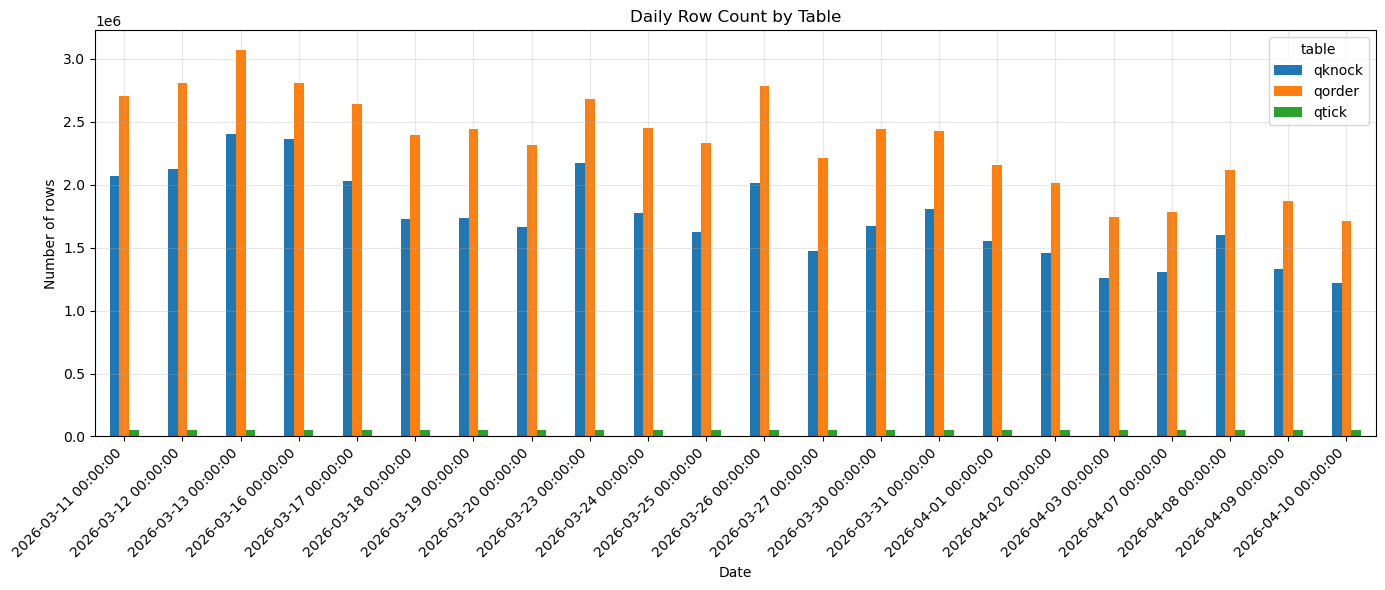

In [31]:
daily_volume_queries = {
    table_name: f'''
        select date, count(*) as n_rows
        from loadTable("{db_path}", "{table_name}")
        where date >= {start_date}
          and date <= {end_date}
          and code in {code_list}
        group by date
        order by date
    '''
    for table_name in ["qtick", "qorder", "qknock"]
}

daily_volume_list = []
for table_name, query in daily_volume_queries.items():
    temp = s.run(query)
    temp["table"] = table_name
    daily_volume_list.append(temp)

daily_volume = pd.concat(daily_volume_list, ignore_index=True)
daily_volume["date"] = pd.to_datetime(daily_volume["date"])
display(daily_volume.head())

plot_df = daily_volume.pivot(index="date", columns="table", values="n_rows").fillna(0)
plot_df.plot(kind="bar", figsize=(14, 6))
plt.title("Daily Row Count by Table")
plt.xlabel("Date")
plt.ylabel("Number of rows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### 9.1 Daily Record Distribution across Level-2 Tables
How do qtick, qorder, and qknock differ in record generation mechanism?

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

daily_records = pd.concat(
    [
        qtick_daily.assign(table="qtick"),
        qorder_daily.assign(table="qorder"),
        qknock_daily.assign(table="qknock")
    ],
    ignore_index=True
)

display(daily_records.head())

,date,n_rows,table
0,2026-03-11,50061,qtick
1,2026-03-12,50068,qtick
2,2026-03-13,50060,qtick
3,2026-03-16,50066,qtick
4,2026-03-17,50063,qtick


In [33]:
daily_tables = {
    "qtick": qtick_daily.copy(),
    "qorder": qorder_daily.copy(),
    "qknock": qknock_daily.copy()
}

daily_record_list = []

for table_name, df in daily_tables.items():
    df = df.copy()
    
    if "count" in df.columns:
        df = df.rename(columns={"count": "n_rows"})
    
    df["table"] = table_name
    daily_record_list.append(df[["date", "n_rows", "table"]])

daily_records = pd.concat(daily_record_list, ignore_index=True)

display(daily_records.head())

,date,n_rows,table
0,2026-03-11,50061,qtick
1,2026-03-12,50068,qtick
2,2026-03-13,50060,qtick
3,2026-03-16,50066,qtick
4,2026-03-17,50063,qtick


##### 9.1.1 Daily Record Count Plot

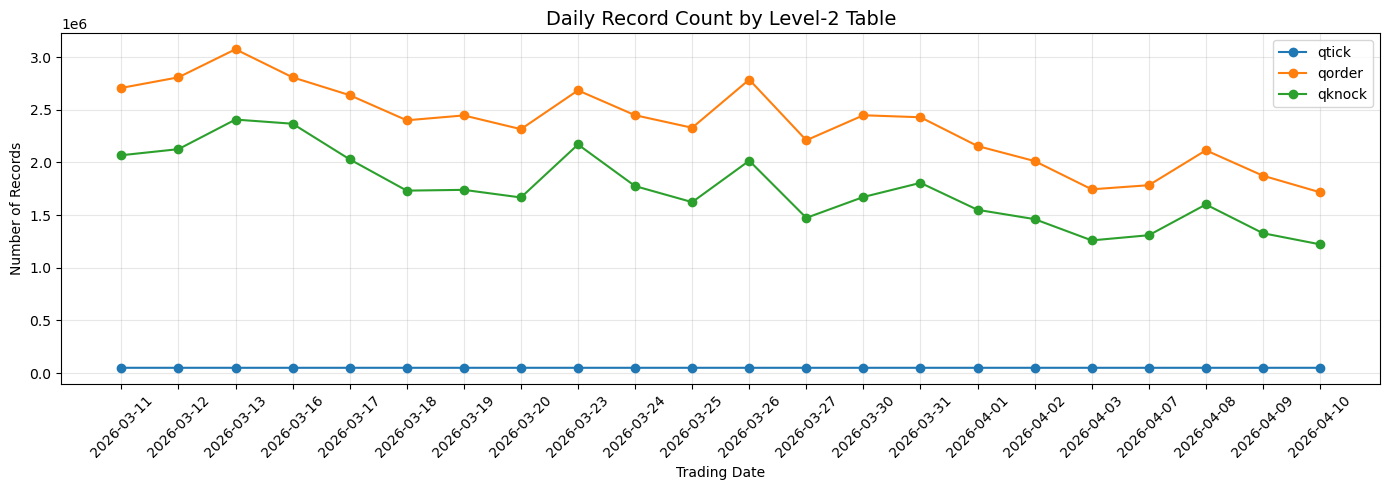

In [34]:
plt.figure(figsize=(14, 5))

for table_name in ["qtick", "qorder", "qknock"]:
    temp = daily_records[daily_records["table"] == table_name]
    plt.plot(
        temp["date"],
        temp["n_rows"],
        marker="o",
        label=table_name
    )

plt.title("Daily Record Count by Level-2 Table", fontsize=14)
plt.xlabel("Trading Date")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### 9.1.2 Record Stability Summary

In [35]:
record_stability_summary = (
    daily_records
    .groupby("table")
    .agg(
        trading_days=("date", "nunique"),
        avg_rows=("n_rows", "mean"),
        min_rows=("n_rows", "min"),
        max_rows=("n_rows", "max"),
        std_rows=("n_rows", "std")
    )
    .reset_index()
)

record_stability_summary["cv"] = (
    record_stability_summary["std_rows"] /
    record_stability_summary["avg_rows"]
)

record_stability_summary["cv"] = record_stability_summary["cv"].map(lambda x: f"{x:.2%}")

record_stability_summary["generation_mechanism"] = record_stability_summary["table"].map({
    "qtick": "Fixed-frequency snapshot",
    "qorder": "Event-driven order records",
    "qknock": "Event-driven trade records"
})

record_stability_summary["interpretation"] = record_stability_summary["table"].map({
    "qtick": "Record count mainly reflects sampling frequency",
    "qorder": "Record count reflects order submission / cancellation activity",
    "qknock": "Record count reflects executed trading activity"
})

display(record_stability_summary)

,table,trading_days,avg_rows,min_rows,max_rows,std_rows,cv,generation_mechanism,interpretation
0,qknock,22,1.745151e+06,1221767,2406303,346848.619921,19.87%,Event-driven trade records,Record count reflects executed trading activity
1,qorder,22,2.360091e+06,1716012,3073619,380054.994936,16.10%,Event-driven order records,Record count reflects order submission / cance...
2,qtick,22,5.006473e+04,50060,50070,3.466600,0.01%,Fixed-frequency snapshot,Record count mainly reflects sampling frequency


##### 9.1 Interpretation

The three Level-2 tables exhibit different daily record distributions because they are generated by different mechanisms.

`qtick` is a fixed-frequency quote snapshot table. Its daily record count is highly stable, indicating that quote snapshots are collected at a consistent frequency across trading days.

In contrast, `qorder` and `qknock` are event-driven tables. Their record counts naturally fluctuate because order submissions, cancellations, and executed trades depend on market activity.

Therefore, daily variation in `qorder` and `qknock` should not be interpreted as missing data. Instead, it reflects changes in market participation and trading intensity.

#### 9.2 Order Activity versus Trade Activity
How does order activity compare with executed trade activity across trading days?

Since not every submitted order results in a trade, comparing `qorder` and `qknock` helps reveal the relationship between order flow and execution intensity.

In [36]:
daily_pivot = (
    daily_records
    .pivot(index="date", columns="table", values="n_rows")
    .reset_index()
)

daily_pivot["order_to_trade_ratio"] = (
    daily_pivot["qorder"] / daily_pivot["qknock"]
)

daily_pivot["trade_to_order_ratio"] = (
    daily_pivot["qknock"] / daily_pivot["qorder"]
)

display(daily_pivot.head())

table,date,qknock,qorder,qtick,order_to_trade_ratio,trade_to_order_ratio
0,2026-03-11,2067720,2706801,50061,1.309075,0.763898
1,2026-03-12,2125495,2807221,50068,1.320738,0.757153
2,2026-03-13,2406303,3073619,50060,1.277320,0.782889
3,2026-03-16,2366717,2807139,50066,1.186090,0.843106
4,2026-03-17,2028920,2637983,50063,1.300191,0.769118


##### 9.2.1 Order-to-Trade Ratio Plot


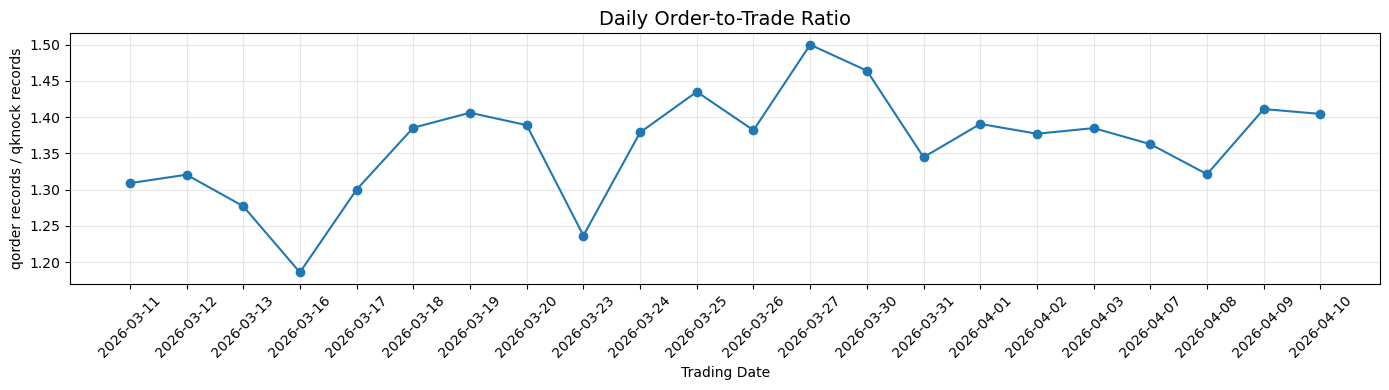

In [37]:
plt.figure(figsize=(14, 4))

plt.plot(
    daily_pivot["date"],
    daily_pivot["order_to_trade_ratio"],
    marker="o"
)

plt.title("Daily Order-to-Trade Ratio", fontsize=14)
plt.xlabel("Trading Date")
plt.ylabel("qorder records / qknock records")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The order-to-trade ratio fluctuates within a relatively narrow range throughout the sampling period.

No structural break or abnormal spike is observed.

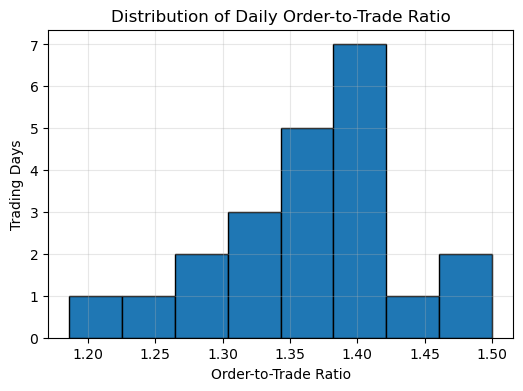

In [38]:
plt.figure(figsize=(6,4))

plt.hist(
    daily_pivot["order_to_trade_ratio"],
    bins=8,
    edgecolor="black"
)

plt.xlabel("Order-to-Trade Ratio")
plt.ylabel("Trading Days")

plt.title("Distribution of Daily Order-to-Trade Ratio")

plt.grid(alpha=0.3)

plt.show()

The histogram shows that most trading days are concentrated around an order-to-trade ratio between 1.3 and 1.4.

This suggests a relatively stable relationship between order generation and trade execution.

##### 9.2.2 Ratio Summary

In [39]:
ratio_summary = pd.DataFrame({
    "Metric":[
        "Average",
        "Std",
        "Minimum",
        "Maximum",
        "Coefficient of Variation"
    ],
    "Value":[
        daily_pivot["order_to_trade_ratio"].mean(),
        daily_pivot["order_to_trade_ratio"].std(),
        daily_pivot["order_to_trade_ratio"].min(),
        daily_pivot["order_to_trade_ratio"].max(),
        daily_pivot["order_to_trade_ratio"].std()/daily_pivot["order_to_trade_ratio"].mean()
    ]
})

ratio_summary["Value"]=ratio_summary["Value"].round(4)

display(ratio_summary)

,Metric,Value
0,Average,1.3622
1,Std,0.0719
2,Minimum,1.1861
3,Maximum,1.5000
4,Coefficient of Variation,0.0528


The coefficient of variation is only 5.3%, indicating that although the market activity changes substantially across trading days, the relative relationship between order events and executed trades remains remarkably stable.

In [40]:
daily_pivot["order_to_trade_zscore"] = (
    (daily_pivot["order_to_trade_ratio"] - daily_pivot["order_to_trade_ratio"].mean()) /
    daily_pivot["order_to_trade_ratio"].std()
)
anomaly_days = daily_pivot[abs(daily_pivot["order_to_trade_zscore"]) > 2]
print(f"异常交易日: {anomaly_days['date'].tolist()}")

异常交易日: ['2026-03-16']


#### 9.3 Research Usage Summary

| Table | Generation Mechanism | What Record Count Means | Research Usage |
|---|---|---|---|
| `qtick` | Fixed-frequency snapshot | Quote collection frequency | Order book depth, bid-ask spread, quote imbalance |
| `qorder` | Event-driven order records | Order submission / cancellation activity | Order flow, cancellation behavior, order imbalance |
| `qknock` | Event-driven trade records | Executed trade activity | Trade intensity, VWAP, realized volume, execution behavior |

##### Implication for Downstream Research

For downstream market microstructure research, `qorder` and `qknock` should be viewed as complementary rather than interchangeable datasets.

`qorder` describes market intentions, while `qknock` describes market executions.

Joint analysis of the two tables provides a more complete representation of the trading process than using either table alone.

**Conclusion**

逐日数据量图用于验证样本覆盖。如果某天三张表同时显著偏低，可能是非交易日、数据权限或数据落库问题；如果只有某一张表异常，则需要单独检查该表。

The three Level-2 tables exhibit very different daily record distributions.

`qtick` maintains an almost constant number of records every trading day, reflecting the fixed-frequency generation of quote snapshots.

In contrast, `qorder` and `qknock` fluctuate substantially across trading days, indicating that order submissions and executed trades are event-driven and closely related to market activity.

These differences should be considered during feature engineering.

Daily changes in `qorder` and `qknock` should not be interpreted as data quality issues, but rather as variations in market activity.

Consequently, order-flow and trade-based features may require normalization (e.g., by trading volume or market activity) when comparing different trading days.

## 10. Trading Session Distribution
把样本数据按交易时段分类。

,session,n_rows
1,morning_continuous,4802
0,afternoon_continuous,4788
2,opening_call_auction,404
3,other,6


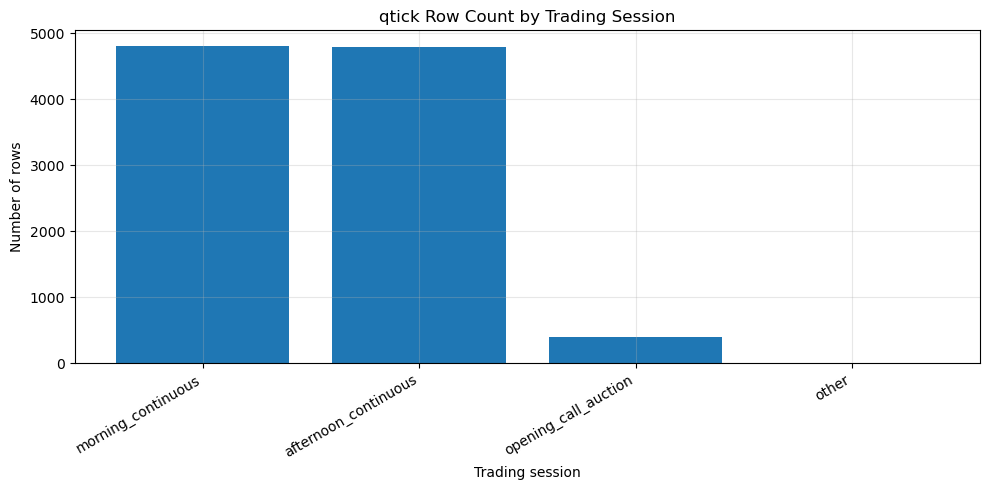

In [41]:
qtick_session = add_session(qtick)
session_count = qtick_session.groupby("session").size().reset_index(name="n_rows")
session_count = session_count.sort_values("n_rows", ascending=False)
display(session_count)

plt.figure(figsize=(10, 5))
plt.bar(session_count["session"], session_count["n_rows"])
plt.title("qtick Row Count by Trading Session")
plt.xlabel("Trading session")
plt.ylabel("Number of rows")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Conclusion**

连续竞价通常占据主要样本量，而开盘集合竞价虽然时间短，但对价格发现、订单簿变化和短期流动性分析很重要。

## 11. DolphinDB `bar`: Minute-level Aggregation
使用 DolphinDB 的 `bar` 对时间字段做分钟聚合。

,code,date,minute,n_ticks,avg_price,min_price,max_price
0,600105.SH,2026-03-11,1970-01-01 09:30:00,20,28.3190,28.20,28.40
1,600105.SH,2026-03-11,1970-01-01 09:31:00,20,28.5030,28.40,28.60
2,600105.SH,2026-03-11,1970-01-01 09:32:00,20,28.5510,28.39,28.75
3,600105.SH,2026-03-11,1970-01-01 09:33:00,20,28.7995,28.70,28.84
4,600105.SH,2026-03-11,1970-01-01 09:34:00,20,28.7770,28.70,28.88


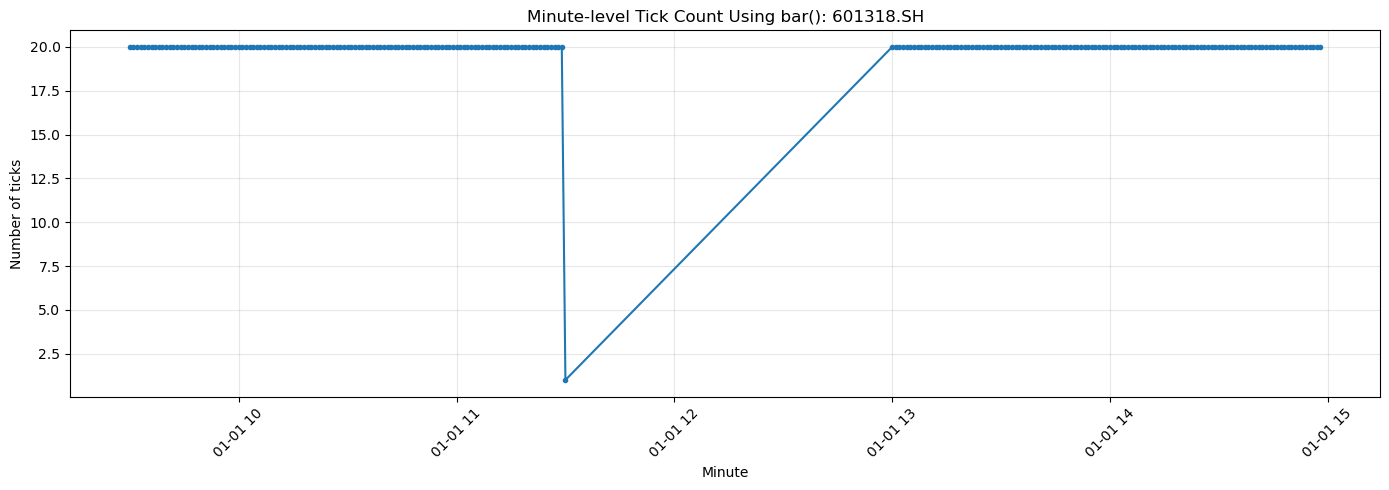

In [42]:
minute_bar_query = f"""
select code, date, minute,
       count(*) as n_ticks,
       avg(new_price) as avg_price,
       min(new_price) as min_price,
       max(new_price) as max_price
from (
    select code, date, time, new_price, bar(time, 1m) as minute
    from loadTable("{db_path}", "qtick")
    where date >= {start_date}
      and date <= {end_date}
      and code in {code_list}
      and time >= 09:30:00.000
      and time <= 15:00:00.000
)
group by code, date, minute
order by code, date, minute
"""

minute_bar = s.run(minute_bar_query)
display(minute_bar.head())

one_code = sample_codes[0]
one_code_minute = minute_bar[minute_bar["code"] == one_code].head(240).copy()

plt.figure(figsize=(14, 5))
plt.plot(pd.to_datetime(one_code_minute["minute"].astype(str)), one_code_minute["n_ticks"], marker="o", markersize=3)
plt.title(f"Minute-level Tick Count Using bar(): {one_code}")
plt.xlabel("Minute")
plt.ylabel("Number of ticks")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Conclusion**

`bar(time, 1m)` 是高频数据降频的核心工具。优先在 DolphinDB 端完成分钟聚合更高效，也更适合大规模数据。

## 12. DolphinDB `context by`: Within-stock Calculation
使用 `context by code` 在每只股票内部计算前一条价格和价格变化。

In [43]:
context_query = f'''
select top 200 code, date, time, new_price,
       prev(new_price) as prev_price,
       new_price - prev(new_price) as price_change
from loadTable("{db_path}", "qtick")
where date >= {start_date}
  and date <= {end_date}
  and code in {code_list}
context by code
order by code, date, time
'''

context_result = s.run(context_query)
display(context_result.head(30))

,code,date,time,new_price,prev_price,price_change
0,600105.SH,2026-03-11,1970-01-01 08:00:00,0.0,NaN,NaN
1,600105.SH,2026-03-11,1970-01-01 08:45:21,0.0,0.0,0.0
2,600105.SH,2026-03-11,1970-01-01 09:14:00,0.0,0.0,0.0
3,600105.SH,2026-03-11,1970-01-01 09:15:00,0.0,0.0,0.0
4,600105.SH,2026-03-11,1970-01-01 09:15:03,0.0,0.0,0.0
5,600105.SH,2026-03-11,1970-01-01 09:15:06,0.0,0.0,0.0
6,600105.SH,2026-03-11,1970-01-01 09:15:09,0.0,0.0,0.0
7,600105.SH,2026-03-11,1970-01-01 09:15:12,0.0,0.0,0.0
8,600105.SH,2026-03-11,1970-01-01 09:15:15,0.0,0.0,0.0
9,600105.SH,2026-03-11,1970-01-01 09:15:18,0.0,0.0,0.0


**Conclusion**

`context by` 适合做股票内部的滚动、滞后和变化率计算。这里的 `prev(new_price)` 不会错误引用其他股票的价格。

## 13. DolphinDB `aj`: As-of Join
`aj` 用于时间对齐，例如把盘口快照对齐到最近一条成交记录。

In [44]:
aj_query = f'''
tick_sample = select top 500 code, date, time, bp0, ap0, new_price
from loadTable("{db_path}", "qtick")
where date >= {start_date}
  and date <= {end_date}
  and code = "{sample_codes[0]}"
order by code, date, time

knock_sample = select top 500 *
from loadTable("{db_path}", "qknock")
where date >= {start_date}
  and date <= {end_date}
  and code = "{sample_codes[0]}"
order by code, date, time

aj(tick_sample, knock_sample, `code`date`time)
'''

aj_result = s.run(aj_query)
display(aj_result.head())
print("aj result shape:", aj_result.shape)

,code,date,time,bp0,ap0,new_price,knock_sample_time,match_no,bid_order_no,ask_order_no,match_price,match_volume
0,601318.SH,2026-03-11,1970-01-01 08:00:00,0.00,0.00,0.0,NaT,NaN,NaN,NaN,NaN,NaN
1,601318.SH,2026-03-11,1970-01-01 08:45:17,0.00,0.00,0.0,NaT,NaN,NaN,NaN,NaN,NaN
2,601318.SH,2026-03-11,1970-01-01 09:14:02,0.00,0.00,0.0,NaT,NaN,NaN,NaN,NaN,NaN
3,601318.SH,2026-03-11,1970-01-01 09:15:02,62.00,62.00,0.0,NaT,NaN,NaN,NaN,NaN,NaN
4,601318.SH,2026-03-11,1970-01-01 09:15:05,61.77,61.77,0.0,NaT,NaN,NaN,NaN,NaN,NaN


aj result shape: (500, 12)


**Conclusion**

`aj` 的核心是“按时间向前找最近记录”。在 Level-2 研究中，它比普通 merge 更适合处理不同表更新时间不完全一致的问题。

## 14. DolphinDB `ej`: Exact Join
`ej` 用于完全匹配字段的连接。这里先检查 `qorder` 和 `qknock` 的公共字段，再用稳定公共键做示例。

In [45]:
print("qorder columns:")
print(qorder.columns.tolist())

print()
print("qknock columns:")
print(qknock.columns.tolist())

common_cols = sorted(set(qorder.columns) & set(qknock.columns))
print()
print("Common columns between qorder and qknock:")
print(common_cols)

qorder columns:
['code', 'date', 'time', 'order_no', 'bs_flag', 'order_type', 'order_price', 'order_volume', 'datetime']

qknock columns:
['code', 'date', 'time', 'match_no', 'bid_order_no', 'ask_order_no', 'match_price', 'match_volume', 'datetime']

Common columns between qorder and qknock:
['code', 'date', 'datetime', 'time']


In [46]:
preferred_keys = ["code", "date", "time"]
join_keys = [key for key in preferred_keys if key in common_cols]

if len(join_keys) < 2:
    print("Not enough common keys for a stable ej example. Please inspect common_cols above.")
else:
    join_key_sql = "`" + "`".join(join_keys)
    ej_query = f'''
    order_sample = select top 1000 *
    from loadTable("{db_path}", "qorder")
    where date >= {start_date}
      and date <= {end_date}
      and code = "{sample_codes[0]}"
    order by code, date, time

    knock_sample = select top 1000 *
    from loadTable("{db_path}", "qknock")
    where date >= {start_date}
      and date <= {end_date}
      and code = "{sample_codes[0]}"
    order by code, date, time

    ej(order_sample, knock_sample, {join_key_sql})
    '''
    ej_result = s.run(ej_query)
    display(ej_result.head())
    print("ej result shape:", ej_result.shape)
    print("join keys:", join_keys)

,code,date,time,order_no,bs_flag,order_type,order_price,order_volume,match_no,bid_order_no,ask_order_no,match_price,match_volume


ej result shape: (0, 13)
join keys: ['code', 'date', 'time']


**Conclusion**

`ej` 强调“完全相等”的连接，适合订单号、成交号、代码、日期等精确字段。若用 `time` 精确匹配，结果可能偏少。

## 15. Final Summary

In [47]:
print_conclusion(
    "Week 2 Overall Findings",
    [
        "The notebook uses loadTable with date, code, and time filters to safely query large Level-2 tables.",
        "The stock universe is restricted to A-share equity codes, avoiding futures contracts such as SHFE and INE products.",
        "qtick, qorder, and qknock provide complementary views of quotes, orders, and trades.",
        "Datetime processing enables minute-level aggregation and trading-session analysis.",
        "Missing-rate and daily-volume checks provide basic data-quality validation before deeper research.",
        "DolphinDB context by, bar, aj, and ej are demonstrated with practical Level-2 examples."
    ]
)


Week 2 Overall Findings
1. The notebook uses loadTable with date, code, and time filters to safely query large Level-2 tables.
2. The stock universe is restricted to A-share equity codes, avoiding futures contracts such as SHFE and INE products.
3. qtick, qorder, and qknock provide complementary views of quotes, orders, and trades.
4. Datetime processing enables minute-level aggregation and trading-session analysis.
5. Missing-rate and daily-volume checks provide basic data-quality validation before deeper research.
6. DolphinDB context by, bar, aj, and ej are demonstrated with practical Level-2 examples.


## 16. Optional Export
如果需要交付 CSV，可以取消下面代码的注释。默认 notebook 直接 `display()` 和画图即可。

In [48]:
# output_dir = "../output"
# os.makedirs(output_dir, exist_ok=True)
# missing_df.to_csv(os.path.join(output_dir, "week2_missing_rate.csv"), index=False)
# daily_volume.to_csv(os.path.join(output_dir, "week2_daily_volume.csv"), index=False)
# code_df.to_csv(os.path.join(output_dir, "week2_sample_universe.csv"), index=False)
# print("CSV files exported to", output_dir)